# compare refined ensemble vs single model trained on all data by looking at MEIs and comparing them with STA temporal traces

In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pickle
import sys

repo_path = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/"
sys.path.append(repo_path)

import thesis.code.validate_online_meis.utils as ut

In [3]:
from thesis.code.plot import plot as plotter

plotter.set_default_params(kind='paper')

In [42]:
DATA_DIR ="/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/validate_online_meis"
FIG_DIR = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/figures/validate_online_meis"
os.makedirs(FIG_DIR,exist_ok=True)

# load data

In [5]:
# enseble model mei container, single member, and srf and trf 
ensemble_conatiner_path = "GCL0_20251003_200456_full_dataset_single_member/mei_data_container.pkl"
member_container_path = "GCL0_20251003_212914_refined_ensemble/mei_data_container.pkl"
ensemble_container = ut.load_file_from_pickle(os.path.join(DATA_DIR,ensemble_conatiner_path))
member_container = ut.load_file_from_pickle(os.path.join(DATA_DIR,member_container_path))

# rfs 
roi_strfs_path = "roi_id_srf_trf.pkl"
roi_srf_trf = ut.load_file_from_pickle(os.path.join(DATA_DIR,roi_strfs_path))

In [6]:
# add extra columns for easier plotting
ensemble_container.head(1)

,readout_idx,roi_id,mei_id,seed,mei,temporal_kernels,spatial_kernels,stability,responses_all_readout_idx,mean_responses_all_readout_idx
0,4,15,roi_15_seed_111,111,"[[[tensor([-4.5027e-04, -9.4331e-04, -1.4040e-...","[[-0.0046140673, -0.010657172, -0.018991489, -...","[[[0.07520435, 0.15755327, 0.2345057, 0.291813...",unstable,"[[0.8427885, 0.9808668, 7.7556334, 6.6358795, ...","[3.677323, 2.2273295, 3.5834064, 3.6441886, 3...."


In [7]:
ensemble_container = ut.add_summed_kernels_column(ensemble_container,"temporal_kernels")
ensemble_container.head(1)

,readout_idx,roi_id,mei_id,seed,mei,temporal_kernels,spatial_kernels,stability,responses_all_readout_idx,mean_responses_all_readout_idx,summed_temporal_kernels
0,4,15,roi_15_seed_111,111,"[[[tensor([-4.5027e-04, -9.4331e-04, -1.4040e-...","[[-0.0046140673, -0.010657172, -0.018991489, -...","[[[0.07520435, 0.15755327, 0.2345057, 0.291813...",unstable,"[[0.8427885, 0.9808668, 7.7556334, 6.6358795, ...","[3.677323, 2.2273295, 3.5834064, 3.6441886, 3....","[-0.012334051, -0.025537472, -0.038996805, -0...."


In [8]:
roi_srf_trf_df = pd.DataFrame({
    "roi_id": roi_srf_trf[0],
    "srf": roi_srf_trf[1],
    "trf": roi_srf_trf[2]
})

# correct the sign depending on srf polatrity

roi_srf_trf_df["trf_signed"] =roi_srf_trf_df.apply(lambda row: ut.adjust_trf_sign(srf =row["srf"],trf=row["trf"]),axis=1)
roi_srf_trf_df.head(1)


,roi_id,srf,trf,trf_signed
0,5,"[[-0.00640598, -0.0050259423, 0.0048288973, 0....","[-0.14409304, -0.104920365, -0.060143426, -0.0...","[-0.14409304, -0.104920365, -0.060143426, -0.0..."


In [9]:
# get times for plotting
n_ts_trf = roi_srf_trf[2][0].shape[0]
trf_times = ut.get_time_vector(n_ts_trf,dt=0.05,t_stop= 0.0)
print(trf_times)

temp_kernel_times = ut.get_time_vector(50,dt=1/30,t_stop= 0.0)

[-0.95 -0.9  -0.85 -0.8  -0.75 -0.7  -0.65 -0.6  -0.55 -0.5  -0.45 -0.4
 -0.35 -0.3  -0.25 -0.2  -0.15 -0.1  -0.05  0.  ]


In [34]:
rois_to_plot = np.random.choice(ensemble_container[ensemble_container["stability"]=='stable']["roi_id"],35,replace=False)


[ 47 103  71  45   8  42  39  14  89  21  22  68  62  78  73  26  27  24
   5  61  36  67  48  44  38  40  59  63  49  41  81  84  94  46  28]


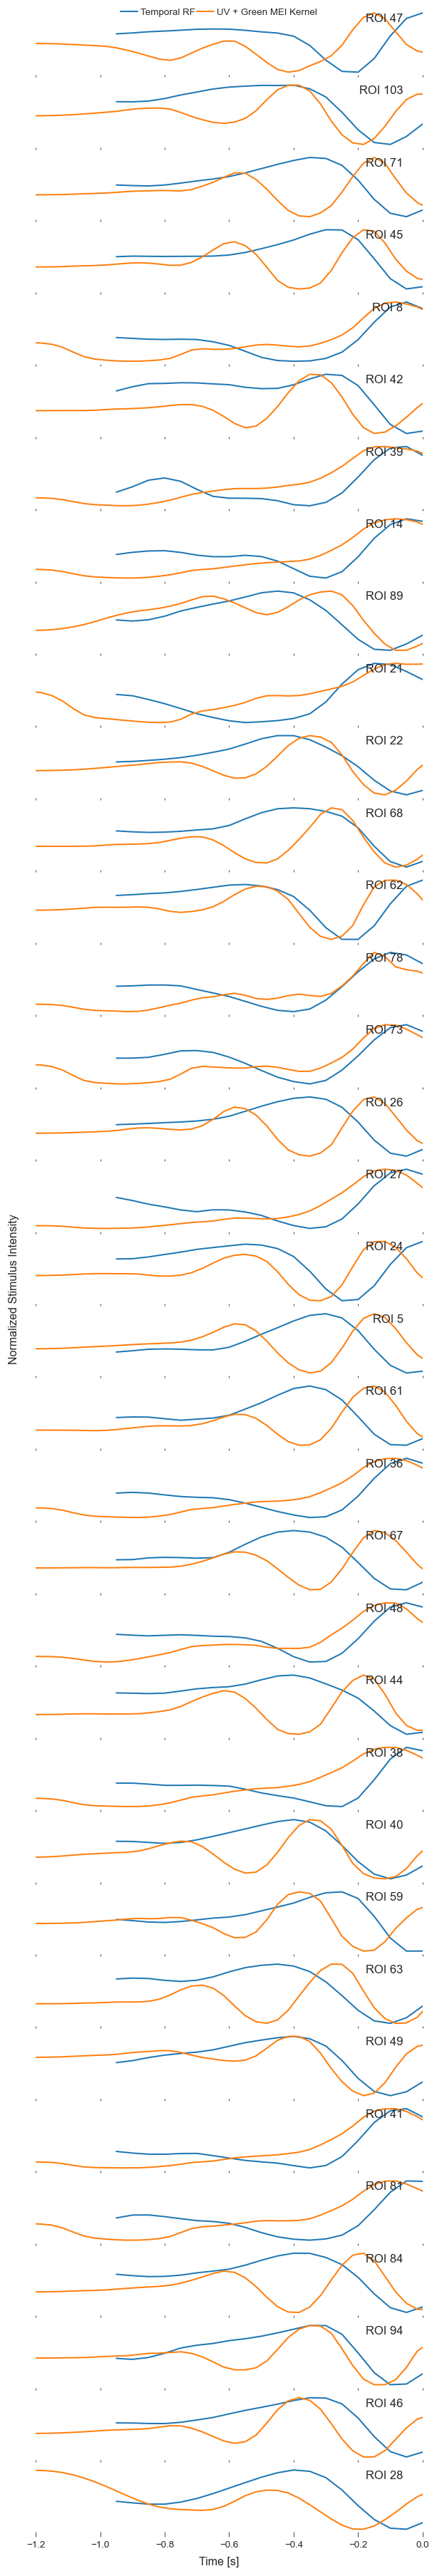

In [ ]:
print(rois_to_plot)

# Prepare data for plotting
plot_data = ut.prepare_trf_kernel_data_for_plotting(
    roi_ids=rois_to_plot,
    roi_data_df=roi_srf_trf_df,
    kernel_data_df=ensemble_container,
    trf_column="trf_signed",
    kernel_column="summed_temporal_kernels",
    trf_dt=0.05,
    kernel_dt=1/30
)

# Create the plot using the prepared data with updated parameters
fig = ut.plot_multiple_trf_temp_kernel_comparisons(
    trfs=plot_data['trfs'],
    temp_kernels=plot_data['temp_kernels'],
    t_trfs=plot_data['t_trfs'],
    t_temp_kernels=plot_data['t_temp_kernels'],
    celltypes=plot_data['celltypes'],
    figsize=(5, 30),
    trf_labels=["Temporal RF"] * len(rois_to_plot),
    temp_kernel_labels=["UV + Green MEI Kernel"] * len(rois_to_plot),
    xlabel="Time [s]",
    ylabel="Normalized Stimulus Intensity",
    time_window=(-1.2,0),
    shift_kernel_by=0.15,
    remove_individual_labels=True  # New parameter to indicate we want shared labels
)


[47, 103, 71, 45, 8, 42, 39, 14, 89, 21, 22, 68, 62]


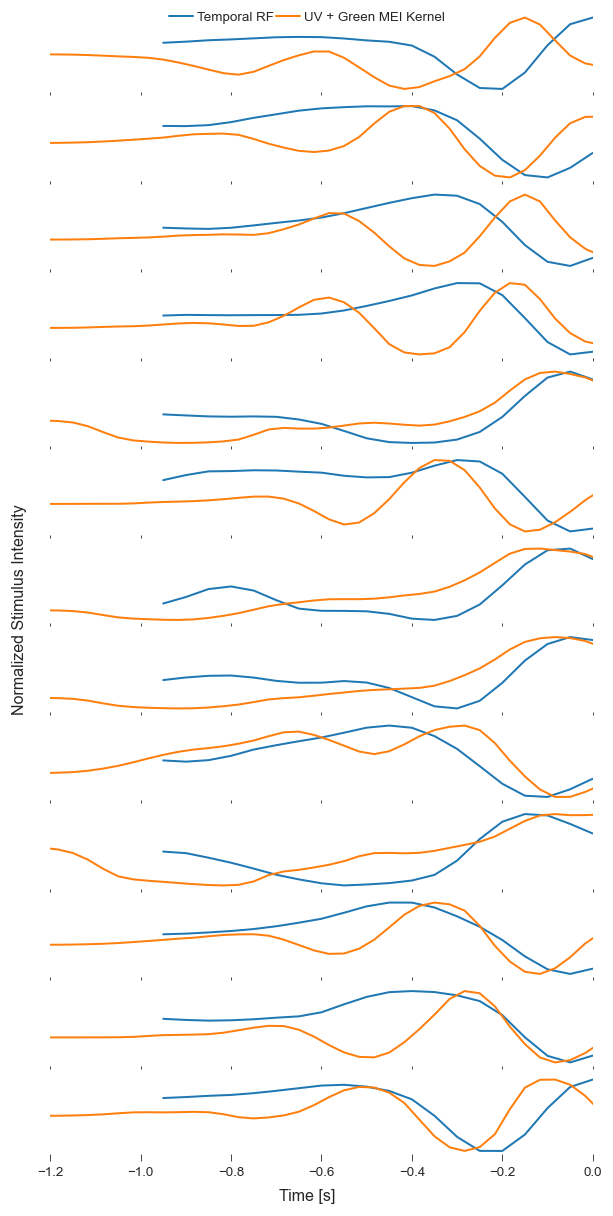

In [40]:
subset = [47 ,103 , 71 , 45  , 8  ,42 , 39 , 14,  89,  21 , 22  ,68 ,62]
print(subset)

# Prepare data for plotting
plot_data = ut.prepare_trf_kernel_data_for_plotting(
    roi_ids=subset,
    roi_data_df=roi_srf_trf_df,
    kernel_data_df=ensemble_container,
    trf_column="trf_signed",
    kernel_column="summed_temporal_kernels",
    trf_dt=0.05,
    kernel_dt=1/30
)

# Create the plot using the prepared data with updated parameters
fig = ut.plot_multiple_trf_temp_kernel_comparisons(
    trfs=plot_data['trfs'],
    temp_kernels=plot_data['temp_kernels'],
    t_trfs=plot_data['t_trfs'],
    t_temp_kernels=plot_data['t_temp_kernels'],
    celltypes=None, #plot_data['celltypes'],
    figsize=(5, 10),
    trf_labels=["Temporal RF"] * len(subset),
    temp_kernel_labels=["UV + Green MEI Kernel"] * len(subset),
    xlabel="Time [s]",
    ylabel="Normalized Stimulus Intensity",
    time_window=(-1.2,0),
    shift_kernel_by=0.15,
    remove_individual_labels=True  # New parameter to indicate we want shared labels
)

In [43]:
plotter.tight_layout()

# save
fig.savefig(os.path.join(FIG_DIR, "ensemble_model_kernel_sum_vs_trf.svg"))

<Figure size 900x300 with 0 Axes>